## Imports

In [ ]:
from   pathlib import Path
import pickle

from neuralhydrology.datasetzoo     import register_dataset

from custom.dataset.swisshourly import SwissHourly
register_dataset("swisshourly", SwissHourly)

from custom.functions.Plot import plot_mape_horizon
from custom.functions.utils_fla import mape_array, dict_without_xr_key


**Idea**

Give two epochs at which the score over the entire horizon will be computed. The goal is to observe if there is any global progress of the score, eventhough the score of the last point does not improve.

**REMINDER**

The metrics displayed during validation period are computed only on the last predicted element. While the validation loss is computed on the entire horizon.

In [ ]:
# Need a run folder !!!
runFolder = "" # path to the run folder
basin = "massa_with_RS"
verb = False

model_str1 = f"model_epoch025"
model_str2 = f"model_epoch040"
valPath1 = Path(runFolder / "validation" / f"{model_str1}" / "validation_results.p")
valPath2 = Path(runFolder / "validation" / f"{model_str2}" / "validation_results.p")

with open(valPath1, "rb") as fp:
    results1 = pickle.load(fp)
with open(valPath2, "rb") as fp:
    results2 = pickle.load(fp)

results1_ = results1[basin]["1h"]["xr"]
results2_ = results2[basin]["1h"]["xr"]
scores1 = dict_without_xr_key(results1[basin]['1h'])
scores2 = dict_without_xr_key(results2[basin]['1h'])

# store only the values in numpy arrays from xarray DataArrays
y_true1 = results1_['streamflow_obs']
y_pred1 = results1_['streamflow_sim']
y_true2 = results2_['streamflow_obs']
y_pred2 = results2_['streamflow_sim']

if verb: 
    print("\n-- Calculating MAPE values for each horizon: --\n")
    mapes1 = mape_array(y_true1, y_pred1, verbose=verb)
    mapes2 = mape_array(y_true2, y_pred2, verbose=verb)
    print("\n-- MAPE calculation per horizon completed. --\n")
else:
    mapes1 = mape_array(y_true1, y_pred1, verbose=verb)
    mapes2 = mape_array(y_true2, y_pred2, verbose=verb)


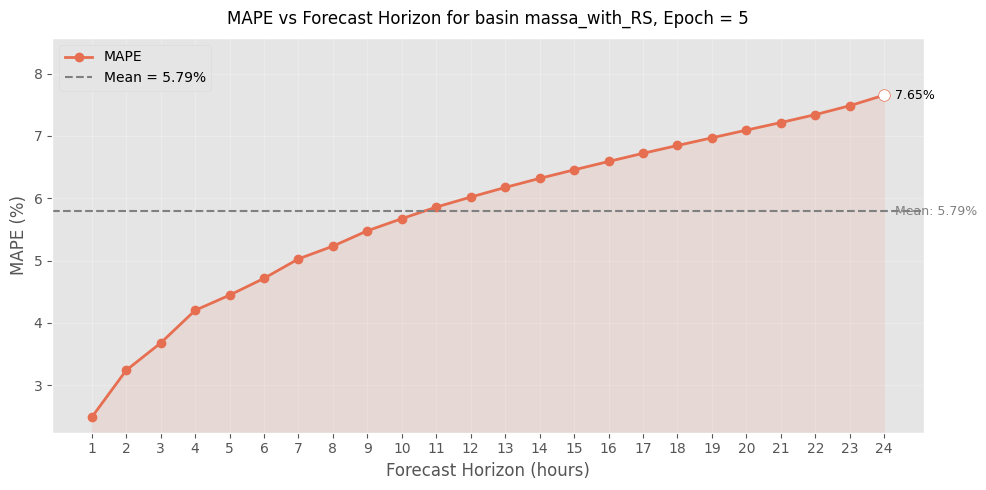

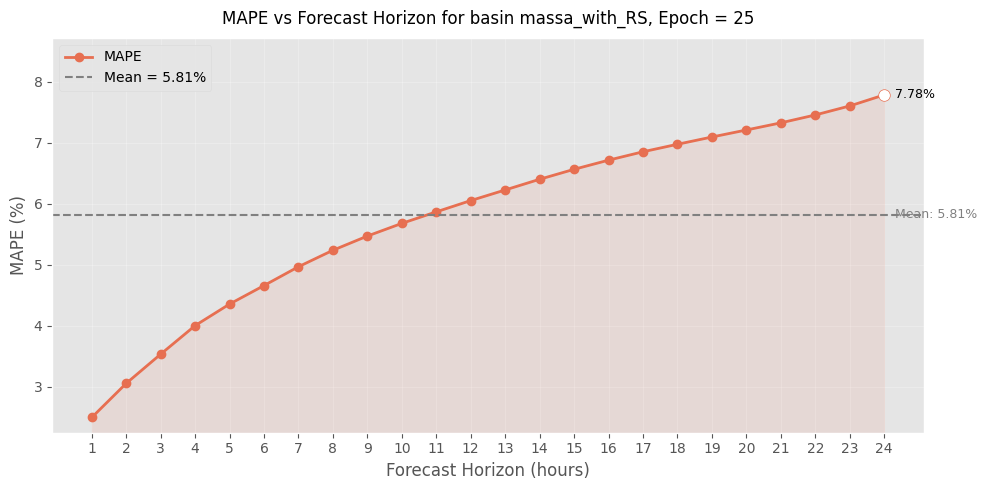

In [ ]:
plot_mape_horizon(
    mapes1,
    color="#e76f51",
    title=f"MAPE vs Forecast Horizon for basin {basin}, {model_str1}"
)

plot_mape_horizon(
    mapes2,
    color="#e76f51",
    title=f"MAPE vs Forecast Horizon for basin {basin}, {model_str2}"
)
